# Amazon Sales Behavior Analysis: Discounts, Ratings, Reviews, and Purchasing Patterns

# What Drives Online Purchases?  
### A Data Mining Study of Pricing and Social Proof in Amazon Sales

# 1. Project Overview

Online retailers often **assume** that **higher discounts, better ratings**, and **more reviews lead to stronger sales**.  
This project **tests** whether those assumptions **are supported by data**.

Using an **Amazon sales dataset** with **50,000 transactions**, I analyze whether product-level signals such as discount tier, rating tier, and review count are meaningfully associated with quantity sold across product categories.

The final notebook focuses on **two tightly connected questions**:

1. Are **higher discounts** and **higher ratings** associated with **higher quantity sold**?
2. Are **higher review counts** associated with **higher quantity sold**?

# 2. Data Overview & Setup

The dataset contains transaction-level **Amazon sales records**, including **product category**, **discount percentage, rating, review count, quantity sold, payment method**, and **customer region**.


Several **numerical variables** were converted into **categorical tiers**:

- Discount percentage → Low, Mid, High discount
- Rating → Poor, Average, High rating
- Quantity sold → Single, Multi, Bulk quantity
- Review count → Niche, Steady, Popular reviews

This binning step allowed the project to use association rule mining and frequent itemset mining more effectively.

In [ ]:
import warnings
import logging
warnings.filterwarnings("ignore")
logging.getLogger("jupyter_client").setLevel(logging.ERROR)

# Load cleaned dataset and create bins
import pandas as pd
import kagglehub
import os

path = kagglehub.dataset_download("aliiihussain/amazon-sales-dataset")
csv_path = os.path.join(path, "amazon_sales_dataset.csv")
df = pd.read_csv(csv_path)

df['disc_bin'] = pd.cut(df['discount_percent'], bins=[-1, 5, 20, 31],
                        labels=['Low_Disc', 'Mid_Disc', 'High_Disc'])
df['rate_bin'] = pd.cut(df['rating'], bins=[0, 2, 4, 5.1],
                        labels=['Poor_Rate', 'Avg_Rate', 'High_Rate'])
df['qty_bin'] = pd.cut(df['quantity_sold'], bins=[0, 1, 3, 6],
                       labels=['Single_Qty', 'Multi_Qty', 'Bulk_Qty'])
df['review_bin'] = pd.cut(df['review_count'], bins=[-1, 100, 300, 501],
                          labels=['Niche', 'Steady', 'Popular'])

print(df.shape)
df

Using Colab cache for faster access to the 'amazon-sales-dataset' dataset.
(50000, 17)


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,disc_bin,rate_bin,qty_bin,review_bin
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,Mid_Disc,Avg_Rate,Bulk_Qty,Popular
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,Mid_Disc,Avg_Rate,Bulk_Qty,Popular
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,Mid_Disc,High_Rate,Multi_Qty,Steady
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,Mid_Disc,High_Rate,Bulk_Qty,Steady
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,Low_Disc,High_Rate,Bulk_Qty,Popular
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95,Low_Disc,Avg_Rate,Bulk_Qty,Popular
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05,Mid_Disc,Avg_Rate,Bulk_Qty,Niche
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92,High_Disc,Avg_Rate,Bulk_Qty,Steady
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16,Low_Disc,Poor_Rate,Single_Qty,Popular


# 3. The Questions We’re Trying to Answer
### Research Question 1
Within each **product category**, are **higher discount tiers** and **higher rating tiers** associated with **higher quantity sold**?

### Research Question 2
Across **product categories**, are **higher review counts** associated with **higher sales quantity**?

# 4. How the Analysis Works

This project uses a combination of pattern mining and statistical analysis.

For RQ1, I used Apriori-based Association Rule Mining. This method identifies patterns such as whether high discounts or high ratings tend to appear with bulk purchases. The main evaluation metrics were support, confidence, and lift. Lift was especially important because values close to 1 indicate weak association.

For RQ2, I used cross-tabulation to compare review-count tiers with quantity-sold tiers across product categories. Frequent Itemset Mining was included as supporting exploratory analysis, but not as the main evidence for dependency.

# 5. RQ1:
# Pricing Signals: Do Discounts & Ratings Drive Sales?



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from mlxtend.frequent_patterns import apriori, association_rules
# RQ1: Association rules within each product category

rq1_results = []
for category in df['product_category'].dropna().unique():
    subset = df[df['product_category'] == category][['disc_bin', 'rate_bin', 'qty_bin']]
    encoded = pd.get_dummies(subset)

    itemsets = apriori(encoded, min_support=0.05, use_colnames=True)
    rules = association_rules(itemsets, metric="lift", min_threshold=1.0)

    if not rules.empty:
        rules['product_category'] = category
        rq1_results.append(rules)

rules_rq1 = pd.concat(rq1_results, ignore_index=True)

top_rules_per_category = (
    rules_rq1
    .sort_values(by=['product_category', 'lift', 'confidence', 'support'],
                 ascending=[True, False, False, False])
    .groupby('product_category')
    .head(5)
    .reset_index(drop=True)
)

top_rules_per_category[['product_category', 'antecedents', 'consequents',
                        'support', 'confidence', 'lift']]

,product_category,antecedents,consequents,support,confidence,lift
0,Beauty,(qty_bin_Multi_Qty),"(rate_bin_Poor_Rate, disc_bin_Mid_Disc)",0.055641,0.139308,1.070092
1,Beauty,"(rate_bin_Poor_Rate, disc_bin_Mid_Disc)",(qty_bin_Multi_Qty),0.055641,0.427405,1.070092
2,Beauty,"(qty_bin_Multi_Qty, disc_bin_Mid_Disc)",(rate_bin_Poor_Rate),0.055641,0.280357,1.044093
3,Beauty,(rate_bin_Poor_Rate),"(qty_bin_Multi_Qty, disc_bin_Mid_Disc)",0.055641,0.207215,1.044093
4,Beauty,"(qty_bin_Bulk_Qty, disc_bin_Low_Disc)",(rate_bin_Avg_Rate),0.068990,0.515901,1.032900
5,Books,"(qty_bin_Bulk_Qty, rate_bin_High_Rate)",(disc_bin_Mid_Disc),0.053321,0.527316,1.063444
6,Books,(disc_bin_Mid_Disc),"(qty_bin_Bulk_Qty, rate_bin_High_Rate)",0.053321,0.107532,1.063444
7,Books,(qty_bin_Bulk_Qty),"(rate_bin_High_Rate, disc_bin_Mid_Disc)",0.053321,0.132340,1.062674
8,Books,"(rate_bin_High_Rate, disc_bin_Mid_Disc)",(qty_bin_Bulk_Qty),0.053321,0.428158,1.062674
9,Books,"(qty_bin_Bulk_Qty, disc_bin_Mid_Disc)",(rate_bin_High_Rate),0.053321,0.260105,1.050897


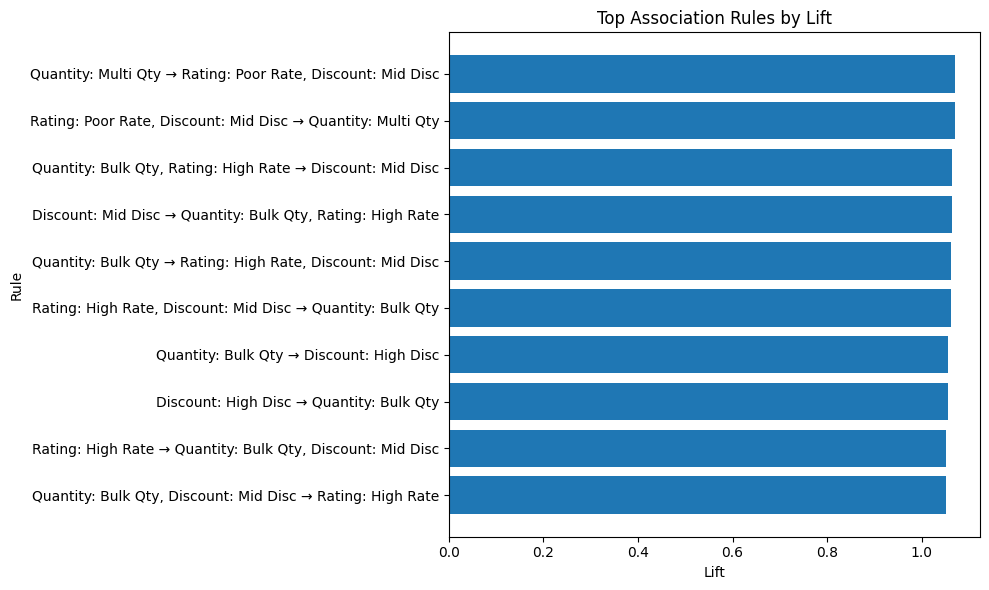

In [ ]:
def format_rule(row):
    def clean(item):
        return item.replace('disc_bin_', 'Discount: ') \
                   .replace('rate_bin_', 'Rating: ') \
                   .replace('qty_bin_', 'Quantity: ') \
                   .replace('_', ' ')

    antecedent = ', '.join([clean(item) for item in row['antecedents']])
    consequent = ', '.join([clean(item) for item in row['consequents']])

    return f"{antecedent} → {consequent}"

top_plot = rules_rq1.sort_values(by='lift', ascending=False).head(10).copy()
top_plot['rule_clean'] = top_plot.apply(format_rule, axis=1)

plt.figure(figsize=(10, 6))
plt.barh(top_plot['rule_clean'], top_plot['lift'])
plt.xlabel('Lift')
plt.ylabel('Rule')
plt.title('Top Association Rules by Lift')
plt.gca().invert_yaxis()  # highest on top
plt.tight_layout()
plt.show()


**Interpretation:**

The association rule results show that rules were found across all product categories, but the lift values were consistently close to 1. This means the relationships between discount tier, rating tier, and quantity sold were weak.

Beauty and Books showed the highest lift values, while Fashion showed the weakest association strength. However, even the strongest rules had lift values only slightly above 1, which suggests that higher discounts and higher ratings are not strong drivers of higher quantity sold.

Overall, RQ1 suggests that common business assumptions about discounts and ratings should be treated cautiously. In this dataset, these factors alone do not strongly explain sales quantity.

# 6. RQ2:
# Social Proof: Do Reviews Influence Purchasing?


In [ ]:
# RQ2 Part 1: Review count vs quantity sold

rq2_review_sales_results = []

for category in df['product_category'].dropna().unique():
    df_cat = df[df['product_category'] == category]

    review_qty_table = pd.crosstab(
        df_cat['review_bin'],
        df_cat['qty_bin'],
        normalize='index'
    )

    prob_bulk = review_qty_table.loc['Popular', 'Bulk_Qty']

    rq2_review_sales_results.append({
        'product_category': category,
        'P(Bulk_Qty | Popular Reviews)': prob_bulk
    })

rq2_review_sales_summary = pd.DataFrame(rq2_review_sales_results)
rq2_review_sales_summary.sort_values(
    by='P(Bulk_Qty | Popular Reviews)',
    ascending=False
)



,product_category,P(Bulk_Qty | Popular Reviews)
1,Fashion,0.418182
3,Beauty,0.406411
0,Books,0.397969
5,Home & Kitchen,0.395028
2,Sports,0.393614
4,Electronics,0.391875


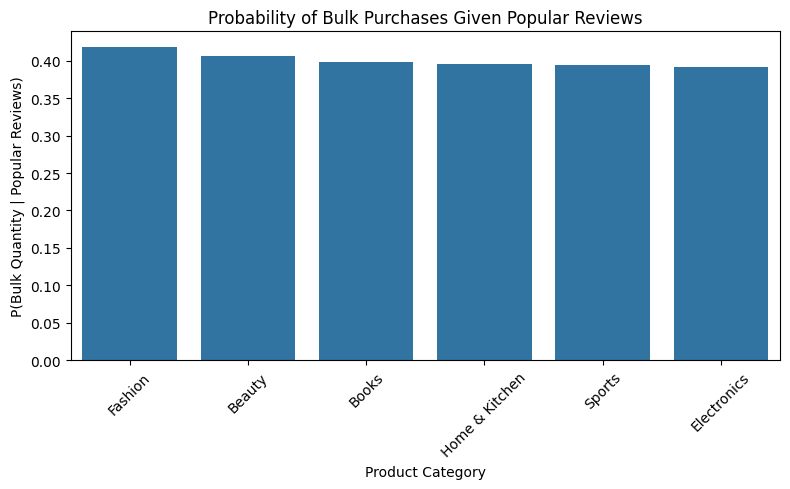

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=rq2_review_sales_summary.sort_values(
        by='P(Bulk_Qty | Popular Reviews)', ascending=False),
    x='product_category',
    y='P(Bulk_Qty | Popular Reviews)'
)
plt.title('Probability of Bulk Purchases Given Popular Reviews')
plt.xlabel('Product Category')
plt.ylabel('P(Bulk Quantity | Popular Reviews)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:**



To evaluate whether review count influences purchasing behavior, I analyzed how quantity sold varies across review-count tiers within each product category.

The results showed that the probability of bulk purchases given popular reviews was very similar across all categories. The values ranged only from approximately 39% to 42%, indicating that higher review count is not strongly associated with higher quantity sold in any specific category.

Overall, these results suggest that review count, as a proxy for social proof, does not strongly drive purchasing quantity in this dataset. While products with more reviews may appear more trustworthy, this effect does not translate into significantly higher quantities sold across product categories.

This finding complements the results from RQ1, reinforcing the conclusion that common e-commerce signals such as discounts, ratings, and review counts alone are not strong predictors of purchasing behavior.

# 7. Overall Conclusion

This project examined whether pricing signals (discounts and ratings) and social proof (review count) are associated with purchasing behavior.

The results showed that both effects are weak. Higher discounts, higher ratings, and higher review counts were not strongly associated with higher quantity sold across product categories.

This does not imply that discounts, ratings, or reviews are unimportant in real-world settings. Instead, it highlights that customer purchasing behavior is more complex and likely influenced by additional factors not captured in this dataset, such as product price, brand reputation, return policies, delivery time, and customer-specific preferences.

The key takeaway is that simple, commonly assumed signals are not sufficient to explain purchasing behavior on their own. A more comprehensive understanding would require richer data and more detailed modeling of customer decision-making.


# 8. Directions for Future Research

The results suggest that pricing signals and review count alone are not strong predictors of purchasing behavior in this dataset. A natural next step would be to incorporate additional variables that more directly capture customer decision-making.

Future work could include features such as product price, brand, return policy, delivery time, and seller reputation. These factors may provide a deeper understanding of what drives purchasing behavior.

Another direction would be to move beyond pattern mining and use predictive models, such as classification or regression, to estimate quantity sold based on multiple features simultaneously.

# Collaboration Declaration

**1. Collaborators:**
* **None.** (I worked independently on this project).

**2. Web Sources:**
* **None.**

**3. AI Tools:**
* **ChatGPT:** Used as a primary collaborator for structuring research questions and code generation. I utilized a series of iterative prompts to define the project scope, including asking what insights could be derived from payment methods and regional discount sensitivity while explicitly excluding anomaly detection as a viable method for this dataset. I prompted the AI to help correlate items sold per transaction to rating and review counts. Further prompts requested the generation of Python code. Finally, I provided the raw EDA results and prompted the AI to draft the Motivation, Feasibility, Methodological Planning, and other sections based on those specific numerical outputs to ensure the report was data-driven and met professional rubric standards.

**4. Citations:**
* **None.**

In [ ]:
!python --version

Python 3.12.13


In [ ]:
!pip freeze > requirements.txt
from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>